In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import glob
import numpy as np
from IPython.display import display
import matplotlib.patheffects as pe

In [2]:
geo = pd.read_csv('/mnt/scratch/baburish/doublepulse/gnn/Analysis/geometry_clean.csv')
X = geo['dom_x']
Y = geo['dom_y']
Z = geo['dom_z']

In [ ]:
connection = sqlite3.connect("/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_train/nutau_gemini_ftp_65TeV_lowerbound_skimmed_chunk_022860.018814_0000.db_train.db")
sql_query = """SELECT name FROM sqlite_master  
  WHERE type='table';"""
cursor = connection.cursor()
cursor.execute(sql_query)
output = cursor.fetchall()
print(output)

[('truth',), ('CleanedROIPulses',), ('reco',)]


In [5]:
connection = sqlite3.connect("/mnt/research/IceCube/lownutau/gemini_moreMC_sqlite/nutau_train/nutau_gemini_ftp_65TeV_lowerbound_skimmed_chunk_022860.018814_0000.db_train.db")
sql_query = """SELECT name FROM sqlite_master  
  WHERE type='table';"""
cursor = connection.cursor()
cursor.execute(sql_query)
output = cursor.fetchall()
print(output)

[('CleanedROIPulses',), ('truth',), ('reco',)]


In [ ]:
df_truth = pd.read_sql_query("SELECT * FROM truth;", connection)
df_pulses = pd.read_sql_query("SELECT * FROM CleanedROIPulses;", connection)
df_reco = pd.read_sql_query("SELECT * FROM reco;", connection)
connection.close()

In [ ]:
print(df_truth.columns)
print(df_pulses.columns)
print(df_reco.columns)

Index(['primary_energy', 'energy', 'position_x', 'position_y', 'position_z',
       'azimuth', 'zenith', 'pid', 'signal', 'sim_type', 'interaction_type',
       'run_id', 'subrun_id', 'event_id', 'subevent_id', 'inelasticity',
       'event_category', 'seed_string', 'tau_prod_vertex_x',
       'tau_prod_vertex_y', 'tau_prod_vertex_z', 'tau_prod_vertex_t',
       'tau_dec_vertex_x', 'tau_dec_vertex_y', 'tau_dec_vertex_z',
       'tau_dec_vertex_t', 'e_prod_vertex_x', 'e_prod_vertex_y',
       'e_prod_vertex_z', 'e_prod_vertex_t', 'mjd', 'TIntProbW', 'OneWeight',
       'Inelasticity_param_a', 'Inelasticity_param_b', 'MCPrimaryType',
       'MCPrimaryAzimuth', 'MCPrimaryEnergy', 'MCPrimaryZenith', 'Event',
       'SubEvent', 'IceScattering', 'IceAbsorption', 'DOMEfficiency',
       'IceAnisotropyScale', 'HoleIceForward_p0', 'HoleIceForward_p1',
       'MuonWeight', 'train_pass', 'event_no'],
      dtype='object')
Index(['charge', 'dom_time', 'dom_x', 'dom_y', 'dom_z', 'event_no'], dtype=

In [6]:
print(df_truth['seed_string'].head())
print(df_pulses['dom_time'].head())

0    43.0
1    48.0
2    44.0
3    12.0
4    69.0
Name: seed_string, dtype: float64
0    1550.0
1    1948.0
2     915.0
3    1368.0
4    1405.0
Name: dom_time, dtype: float64


In [7]:
len(df_pulses)
len(df_truth)

12

In [8]:
df_truth.head()

,primary_energy,energy,position_x,position_y,position_z,azimuth,zenith,pid,signal,sim_type,...,SubEvent,IceScattering,IceAbsorption,DOMEfficiency,IceAnisotropyScale,HoleIceForward_p0,HoleIceForward_p1,MuonWeight,train_pass,event_no
0,2.012304e+07,2.012304e+07,-9.991159e+02,-1.397820e+03,1.947768e+03,4.187072,0.751021,16.0,1.0,genie,...,0.0,1.003558,0.967538,0.939127,None,0.307943,-0.062474,None,1.0,2
1,1.133695e+06,1.133695e+06,-1.053427e+03,-7.075220e+02,1.947874e+03,3.701110,0.659654,-16.0,1.0,genie,...,0.0,0.948085,1.079161,0.900739,None,0.024088,-0.024596,None,1.0,8
2,9.141762e+07,1.509610e+05,-2.840424e+06,-5.083078e+06,-5.780583e+06,4.202838,2.352547,-16.0,1.0,genie,...,0.0,1.075242,0.982365,0.949682,None,-0.046247,-0.097442,None,1.0,9
3,7.643168e+07,7.643168e+07,4.956592e+02,5.394468e+02,1.947958e+03,1.380823,0.484505,16.0,1.0,genie,...,0.0,1.007374,0.914063,1.019217,None,0.286949,-0.001090,None,1.0,12
4,1.324652e+06,1.324652e+06,3.465329e+02,2.145084e+03,1.947630e+03,1.221143,0.745979,-16.0,1.0,genie,...,0.0,1.077139,1.070019,0.952095,None,-0.087726,-0.015638,None,1.0,15


In [11]:
df_pulses.head()

,charge,dom_time,dom_x,dom_y,dom_z,auxiliary,event_no
0,1.025,1804.0,-492.43,-230.16,-251.31,0.0,0
1,0.625,1208.0,-492.43,-230.16,-285.35,0.0,0
2,0.875,1252.0,-492.43,-230.16,-336.41,0.0,0
3,0.975,1607.0,-492.43,-230.16,-353.43,0.0,0
4,0.825,1046.0,-492.43,-230.16,-387.47,0.0,0


In [12]:
grouped_piddf = df_truth.groupby('event_no').agg({
    'pid': lambda x: list(x),
}).reset_index()
grouped_piddf.rename(columns={
    'pid': 'pid',
}, inplace=True)

cols_to_convert = ['pid']

for col in cols_to_convert:
    grouped_piddf[col] = grouped_piddf[col].apply(lambda x: np.array(x))

grouped_df = df_pulses.groupby('event_no').agg({
    'charge': lambda x: list(x),
    'dom_x': lambda x: list(x),
    'dom_y': lambda x: list(x),
    'dom_z': lambda x: list(x),
    'dom_time': lambda x: list(x)
}).reset_index()

grouped_df.rename(columns={
    'charge': 'charge',
    'dom_x': 'dom_x',
    'dom_y': 'dom_y',
    'dom_z': 'dom_z',
    'dom_time': 'dom_time'
}, inplace=True)
cols_to_convert = ['charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time']

for col in cols_to_convert:
    grouped_df[col] = grouped_df[col].apply(lambda x: np.array(x))
df = pd.merge(grouped_df, grouped_piddf, on='event_no', how='inner')

print(grouped_df.columns)
print(grouped_piddf.columns)
print(df.columns)
print(len(df['event_no'],))
print(len(df['pid'],))

Index(['event_no', 'charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time'], dtype='object')
Index(['event_no', 'pid'], dtype='object')
Index(['event_no', 'charge', 'dom_x', 'dom_y', 'dom_z', 'dom_time', 'pid'], dtype='object')
120
120


In [13]:
display(df)

,event_no,charge,dom_x,dom_y,dom_z,dom_time,pid
0,0,"[1.024999976158142, 0.625, 0.875, 0.9750000238...","[-492.43, -492.43, -492.43, -492.43, -492.43, ...","[-230.16, -230.16, -230.16, -230.16, -230.16, ...","[-251.31, -285.35, -336.41, -353.43, -387.47, ...","[1804.0, 1208.0, 1252.0, 1607.0, 1046.0, 1125....",[-16.0]
1,1,"[0.675000011920929, 1.274999976158142, 0.875, ...","[544.07, 544.07, 544.07, 544.07, 544.07, 330.0...","[55.89, 55.89, 55.89, 55.89, 55.89, 127.2, 127...","[-450.38, -467.4, -467.4, -484.42, -484.42, -3...","[1379.0, 1255.0, 1574.0, 1490.0, 1565.0, 1199....",[16.0]
2,2,"[0.9750000238418579, 0.7749999761581421, 0.425...","[-66.7, -66.7, -66.7, -66.7, -66.7, -66.7, -66...","[276.92, 276.92, 276.92, 276.92, 276.92, 276.9...","[497.82, 497.82, 497.82, 497.82, 497.82, 497.8...","[39.0, 47.0, 142.0, 165.0, 179.0, 283.0, 326.0...",[-16.0]
3,3,"[1.5750000476837158, 0.32499998807907104, 0.72...","[-413.46, -290.66, -290.66, -290.66, -290.66, ...","[-327.27, -307.38, -307.38, -307.38, -307.38, ...","[312.37, 504.02, 487.0, 469.98, 469.98, 452.96...","[1787.0, 1830.0, 635.0, 697.0, 1033.0, 462.0, ...",[-16.0]
4,4,"[0.22499999403953552, 1.725000023841858, 2.174...","[194.34, 194.34, 194.34, 194.34, 194.34, 292.9...","[-30.92, -30.92, -30.92, -30.92, -30.92, 5.2, ...","[-142.69, -159.71, -176.74, -176.74, -193.76, ...","[1321.0, 1301.0, 1302.0, 1370.0, 1618.0, 1029....",[16.0]
...,...,...,...,...,...,...,...
115,115,"[0.675000011920929, 1.274999976158142, 1.375, ...","[-313.6, -189.98, -189.98, -189.98, -392.38, -...","[237.44, 257.42, 257.42, 257.42, 334.24, 334.2...","[-349.84, -264.58, -298.62, -315.64, -246.12, ...","[1991.0, 1525.0, 1580.0, 1097.0, 1325.0, 1825....",[-16.0]
116,116,"[0.875, 1.0750000476837158, 0.7250000238418579...","[-324.39, -324.39, -403.14, -403.14, -403.14, ...","[-93.43, -93.43, 3.49, 3.49, 3.49, 3.49, 3.49,...","[-129.63, -146.65, -127.96, -127.96, -127.96, ...","[1928.0, 1721.0, 11.0, 168.0, 206.0, 265.0, 31...",[-16.0]
117,117,"[0.925000011920929, 1.024999976158142, 0.72500...","[237.78, 237.78, 237.78, 237.78, 237.78, 237.7...","[-442.42, -442.42, -442.42, -442.42, -442.42, ...","[127.01, 127.01, 109.99, 75.95, 58.93, 58.93, ...","[1058.0, 1071.0, 942.0, 1174.0, 1664.0, 1997.0...",[16.0]
118,118,"[1.024999976158142, 1.125, 0.2750000059604645,...","[-413.46, -413.46, -413.46, -413.46, -413.46, ...","[-327.27, -327.27, -327.27, -327.27, -327.27, ...","[227.26, 227.26, 210.24, 210.24, 210.24, 193.2...","[1325.0, 1687.0, 735.0, 741.0, 1077.0, 872.0, ...",[16.0]


In [14]:
duplicates = df[df.duplicated(subset=['event_no'])]
print(duplicates)

Empty DataFrame
Columns: [event_no, charge, dom_x, dom_y, dom_z, dom_time, pid]
Index: []


In [15]:
print(len(df['event_no'],))
print(len(df['pid'],))

120
120


In [16]:
%matplotlib inline
def flatten_list_column(col):
    flat_list = []
    for item in col:
        if isinstance(item, list):
            flat_list.extend(item)
        else:
            flat_list.append(item)
    return flat_list
# dfrow = df.iloc[10]
dfrow = df.iloc[df['charge'].apply(sum).idxmax()]
print(df['charge'].apply(sum).idxmax())
print(df_truth.iloc[df['charge'].apply(sum).idxmax()])
# print(dfrow['pid'])
dom_x_flat = flatten_list_column(dfrow['dom_x'])
dom_y_flat = flatten_list_column(dfrow['dom_y'])
dom_z_flat = flatten_list_column(dfrow['dom_z'])
charge_flat = flatten_list_column(dfrow['charge'])

df_redpulses = pd.DataFrame({
    'dom_x': dom_x_flat,
    'dom_y': dom_y_flat,
    'dom_z': dom_z_flat,
    'charge': charge_flat,
    'dom_time': flatten_list_column(dfrow['dom_time'])
})



charge_per_dom = df_redpulses.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()


18
energy                       385340.687023
position_x                    -4475.857351
position_y                     4107.242008
position_z                     1945.105274
azimuth                           2.479658
zenith                            1.228897
pid                                   16.0
event_time            130612472805804112.0
sim_type                             genie
interaction_type                       1.0
elasticity                        0.773418
RunID                         2285900001.0
SubrunID                      4294967295.0
EventID                              937.0
SubEventID                             0.0
dbang_decay_length                    -1.0
track_length                          -1.0
stopped_muon                          -1.0
energy_track                          -1.0
energy_cascade                        -1.0
inelasticity                          -1.0
DeepCoreFilter_13                      0.0
CascadeFilter_13                       1.0
MuonFilt

53691532
47964143

In [17]:
dom_count = df_redpulses.groupby(['dom_x', 'dom_y', 'dom_z']).size().reset_index(name='count')
dom_count = dom_count[dom_count['count'] > 1]
print(dom_count)

      dom_x   dom_y   dom_z  count
3     22.11  509.50 -244.25      2
4     22.11  509.50 -193.19      2
10    54.26  292.97 -224.36      2
12    54.26  292.97 -190.32      3
15    54.26  292.97 -139.25      2
..      ...     ...     ...    ...
145  429.76  351.02 -191.71      8
146  429.76  351.02 -174.69     15
147  429.76  351.02 -157.66      8
148  429.76  351.02 -140.64      7
149  429.76  351.02 -123.62      3

[116 rows x 4 columns]


In [18]:
min(df_redpulses['dom_time']) - min(df_redpulses['dom_time'])

0.0

dom_x    -570.900000
dom_y    -125.140000
dom_z    -453.560000
charge    220.000001
Name: 3, dtype: float64


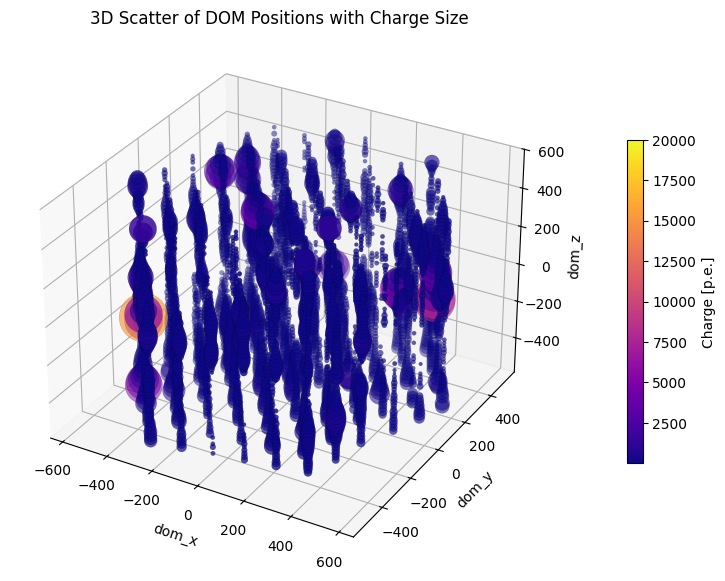

In [28]:
charge_per_dom = df_pulses.groupby(['dom_x', 'dom_y', 'dom_z'])['charge'].sum().reset_index()
charge_per_dom_row = charge_per_dom.iloc[3]
x, y, z, charge = charge_per_dom['dom_x'],charge_per_dom['dom_y'],charge_per_dom['dom_z'], charge_per_dom['charge']
print(charge_per_dom_row) 
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
# im2 = ax.scatter(X, Y, Z, marker='o', s=1)
im = ax.scatter(x, y, z, s=np.sqrt(charge * 100), c=charge, cmap='plasma', edgecolors='k',linewidths=0.1, zorder=100, vmax=20000)
ax.set_xlabel('dom_x')
ax.set_ylabel('dom_y')
ax.set_zlabel('dom_z')
ax.set_title('3D Scatter of DOM Positions with Charge Size')

cbar = plt.colorbar(im, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Charge [p.e.]')

plt.show()

Running trials for 4
Running first for 4, -137.0, 1618.0


NameError: name 'pdf_pages' is not defined

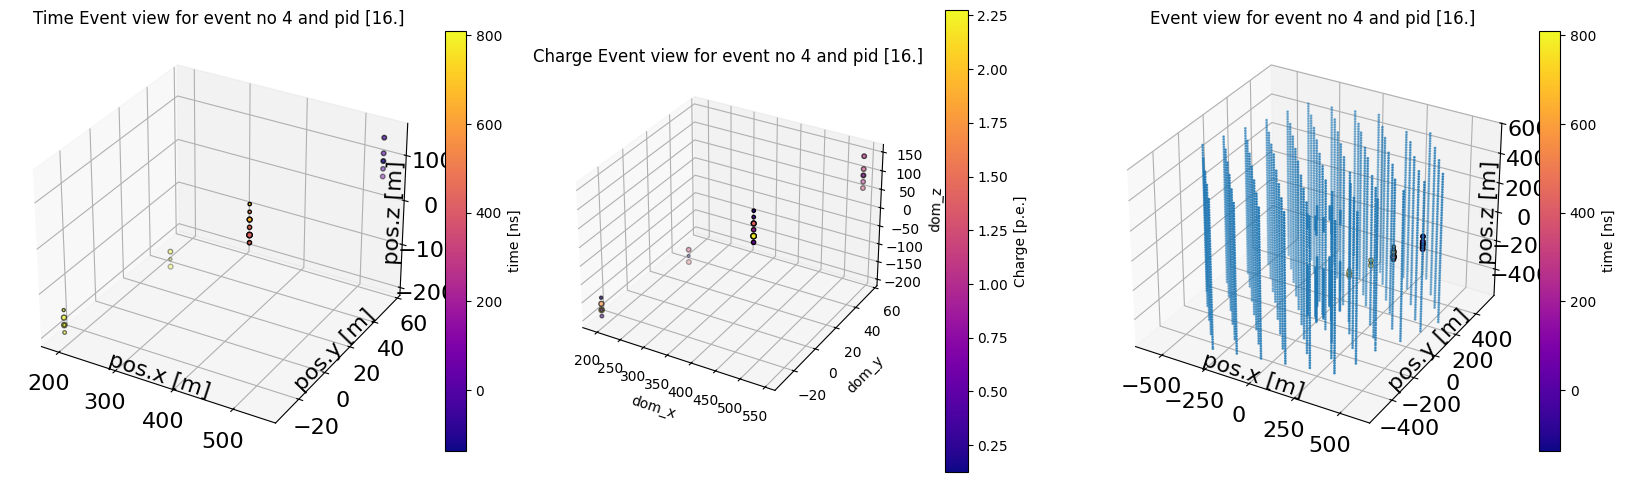

In [33]:
# print("n_doms", len(df_EventSeedPulses))
# for num in range(len(df)):
for num in range(4, 5):
    print(f'Running trials for {num}')
    dfrow = df.iloc[num]
    x = np.array(dfrow['dom_x'])
    y = np.array(dfrow['dom_y'])
    z = np.array(dfrow['dom_z'])
    charge = np.array(dfrow['charge'])
    time = np.array(dfrow['dom_time'])
    pid = np.array(dfrow['pid'])
    fig = plt.figure(figsize=(20, 10))
    ax = fig.add_subplot(131,projection='3d')
    if np.max(time)/2 > 2*np.min(time):
        print(f'Running first for {num}, {np.min(time)}, {np.max(time)}')
        im = ax.scatter(x, y, z,
                        s=np.sqrt(charge * 100),
                        c=time,
                        cmap='plasma',
                        edgecolors='k',
                        # linewidths=0.1,
                        zorder=1000,
                        vmax=np.max(time)/2)
    else:
        print(f'Running second for {num}, {np.min(time)}, {np.max(time)}')
        im = ax.scatter(x, y, z,
                        s=np.sqrt(charge * 100),
                        c=time,
                        cmap='plasma',
                        edgecolors='k',
                        # linewidths=0.1,
                        zorder=1000,
                        vmax=np.max(time))

    fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label='time [ns]')
    ax.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
    ax.set_xlabel('pos.x [m]', fontsize=16, labelpad=-25)
    ax.set_ylabel('pos.y [m]', fontsize=16, labelpad=-25)
    ax.set_zlabel('pos.z [m]', fontsize=16, labelpad=-25)
    ax.set_title(f'Time Event view for event no {num} and pid {pid}')

    ax2 = fig.add_subplot(132, projection='3d')
    im = ax2.scatter(x, y, z, s=np.sqrt(charge * 100), c=charge, cmap='plasma', edgecolors='k', zorder=1000, vmax=np.max(charge))
    ax2.set_xlabel('dom_x')
    ax2.set_ylabel('dom_y')
    ax2.set_zlabel('dom_z')
    ax2.set_title(f'Charge Event view for event no {num} and pid {pid}')
    cbar = plt.colorbar(im, ax=ax2, shrink=0.6, pad=0.1)
    cbar.set_label('Charge [p.e.]')

    ax3 = fig.add_subplot(133,projection='3d')
    im2 = ax3.scatter(X, Y, Z, marker='o', s=1)
    if np.max(time)/2 > 2*np.min(time):
        im = ax3.scatter(x, y, z,
                        s=np.sqrt(charge * 100),
                        c=time,
                        cmap='plasma',
                        edgecolors='k',
                        zorder=1000,
                        vmax=np.max(time)/2)
    else:
        im = ax3.scatter(x, y, z,
                        s=np.sqrt(charge * 100),
                        c=time,
                        cmap='plasma',
                        edgecolors='k',
                        zorder=1000,
                        vmax=np.max(time))

    fig.colorbar(im, orientation='vertical',fraction=0.046, pad=0.04, label='time [ns]')
    ax3.tick_params(axis='both', which='both', width=1.5, colors='0.0', labelsize=16)
    ax3.set_xlabel('pos.x [m]', fontsize=16, labelpad=-25)
    ax3.set_ylabel('pos.y [m]', fontsize=16, labelpad=-25)
    ax3.set_zlabel('pos.z [m]', fontsize=16, labelpad=-25)
    ax3.set_title(f'Event view for event no {num} and pid {pid}')

    pdf_pages.savefig(fig, bbox_inches='tight')
    plt.close(fig)

    min_time = min(dfrow['dom_time'])
    max_time = max(dfrow['dom_time'])
    time_bins = np.linspace(min_time, max_time, 50)
    fig = plt.figure(figsize=(10, 7))
    ax3 = fig.add_subplot(111)
    ax3.hist(dfrow['dom_time'], bins=time_bins, weights=dfrow['charge'])
    ax3.set_ylabel("recorded charge [p.e.]")
    ax3.set_xlabel("detector time [ns]")
    ax3.set_yscale('log')
    ax3.set_title(f"Charge for string {num} and pid {pid}")
    plt.show()
    pdf_pages.savefig(fig, bbox_inches='tight')
    plt.close(fig)

# pdf_pages.close()